In [1]:
# ==============================================================================
# ЯЧЕЙКА 1: Установка необходимых библиотек
# ==============================================================================

!pip install ultralytics gradio scipy opencv-python-headless -q

print("✅ Библиотеки установлены!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 80.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

In [2]:
# ==============================================================================
# ЯЧЕЙКА 2: Импорт библиотек и настройка окружения
# ==============================================================================

import os
import cv2
import glob
import time
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import YOLO
import gradio as gr
from PIL import Image
import requests
from io import BytesIO
import scipy.io as sio

print("✅ Все библиотеки загружены!")

# Проверка GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Устройство: {device}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Все библиотеки загружены!
✅ Устройство: cuda


In [3]:
# ==============================================================================
# ЯЧЕЙКА 3: Загрузка реальных изображений с людьми
# ==============================================================================

print("\n🔄 Загрузка реальных изображений...")

os.makedirs('/kaggle/working/test_images', exist_ok=True)
os.makedirs('/kaggle/working/results', exist_ok=True)

# Реальные изображения с людьми (Pexels)
image_urls = [
    "https://images.pexels.com/photos/1181690/pexels-photo-1181690.jpeg?auto=compress&cs=tinysrgb&w=800",
    "https://images.pexels.com/photos/3012998/pexels-photo-3012998.jpeg?auto=compress&cs=tinysrgb&w=800",
    "https://images.pexels.com/photos/1462637/pexels-photo-1462637.jpeg?auto=compress&cs=tinysrgb&w=800",
    "https://images.pexels.com/photos/1070349/pexels-photo-1070349.jpeg?auto=compress&cs=tinysrgb&w=800",
    "https://images.pexels.com/photos/3184454/pexels-photo-3184454.jpeg?auto=compress&cs=tinysrgb&w=800",
    "https://images.pexels.com/photos/1174647/pexels-photo-1174647.jpeg?auto=compress&cs=tinysrgb&w=800",
    "https://images.pexels.com/photos/1055225/pexels-photo-1055225.jpeg?auto=compress&cs=tinysrgb&w=800",
]

img_list = []
for i, url in enumerate(image_urls):
    try:
        response = requests.get(url, timeout=15)
        img = Image.open(BytesIO(response.content))
        img = img.convert('RGB')
        img = np.array(img)
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        
        # Ресайз
        h, w = img.shape[:2]
        if h > 800:
            scale = 800 / h
            new_w = int(w * scale)
            img = cv2.resize(img, (new_w, 800))
        
        path = f'/kaggle/working/test_images/img_{i+1:04d}.jpg'
        cv2.imwrite(path, img)
        img_list.append(path)
        print(f"  ✅ Загружено изображение {i+1}")
    except Exception as e:
        print(f"  ❌ Ошибка: {e}")

print(f"\n✅ Загружено изображений: {len(img_list)}")


🔄 Загрузка реальных изображений...
  ✅ Загружено изображение 1
  ✅ Загружено изображение 2
  ✅ Загружено изображение 3
  ✅ Загружено изображение 4
  ✅ Загружено изображение 5
  ✅ Загружено изображение 6
  ✅ Загружено изображение 7

✅ Загружено изображений: 7


In [4]:
# ==============================================================================
# ЯЧЕЙКА 4: Загрузка предобученных моделей
# ==============================================================================

print("\n🔄 Загрузка моделей...")

# YOLO модели
yolo = YOLO("yolov8n.pt")
yolo_large = YOLO("yolov8x.pt")
yolo_v5 = YOLO("yolov5nu.pt")
detr = YOLO("rtdetr-l.pt")

# HOG + SVM
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

print("✅ Все модели загружены!")

# Размеры моделей (в Мб)
model_sizes = {
    "YOLOv8n": 6.2,
    "YOLOv8x": 130.0,
    "YOLOv5nu": 5.3,
    "RT-DETR": 66.2,
    "HOG+SVM": 1.1
}


🔄 Загрузка моделей...
✅ Все модели загружены!


In [5]:
# ==============================================================================
# ЯЧЕЙКА 5: Реализация функций подсчёта для каждой архитектуры
# ==============================================================================

def count_yolo(img, model, conf=0.25):
    """Подсчёт людей с помощью YOLO"""
    try:
        results = model(img, conf=conf, verbose=False)
        if results and len(results) > 0:
            boxes = results[0].boxes
            if boxes is not None and len(boxes) > 0:
                person_mask = boxes.cls == 0
                return int(person_mask.sum().item())
        return 0
    except:
        return 0

def count_yolov8n(img):
    return count_yolo(img, yolo, 0.25)

def count_yolov8n_low(img):
    return count_yolo(img, yolo, 0.1)

def count_yolov8x(img):
    return count_yolo(img, yolo_large, 0.25)

def count_yolov5nu(img):
    return count_yolo(img, yolo_v5, 0.25)

def count_rtdetr(img):
    return count_yolo(img, detr, 0.25)

def count_hog(img):
    """Подсчёт людей с помощью HOG + SVM"""
    try:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        boxes, _ = hog.detectMultiScale(
            gray, 
            winStride=(8, 8), 
            padding=(4, 4), 
            scale=1.05
        )
        return len(boxes)
    except:
        return 0

print("✅ Функции подсчёта загружены!")

✅ Функции подсчёта загружены!


In [6]:
# ==============================================================================
# ЯЧЕЙКА 6: Функция визуализации детекций
# ==============================================================================

def visualize_detections(img, model, model_name="YOLOv8"):
    """Визуализация ограничивающих рамок на изображении"""
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_copy = img_rgb.copy()
    count = 0
    
    try:
        results = model(img, conf=0.25, verbose=False)
        if results and len(results) > 0:
            boxes = results[0].boxes
            if boxes is not None and len(boxes) > 0:
                for box in boxes:
                    if box.cls == 0:  # person
                        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                        conf = float(box.conf[0])
                        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
                        cv2.putText(img_copy, f'{conf:.2f}', (x1, y1-10),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                        count += 1
        return img_copy, count
    except Exception as e:
        return img_copy, 0

print("✅ Функция визуализации загружена!")

✅ Функция визуализации загружена!


In [7]:
# ==============================================================================
# ЯЧЕЙКА 7: Запуск экспериментального сравнения
# ==============================================================================

print("\n" + "="*60)
print("ЗАПУСК ЭКСПЕРИМЕНТАЛЬНОГО СРАВНЕНИЯ")
print("="*60)

models = {
    "YOLOv8n": count_yolov8n,
    "YOLOv8x": count_yolov8x,
    "YOLOv5nu": count_yolov5nu,
    "RT-DETR": count_rtdetr,
    "HOG+SVM": count_hog
}

results = {name: {"counts": [], "times": []} for name in models}

print("\n🔄 Оценка моделей...")

for idx, img_path in enumerate(img_list):
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    print(f"  Изображение {idx+1}/{len(img_list)}")
    
    for name, func in models.items():
        start = time.time()
        count = func(img)
        elapsed = (time.time() - start) * 1000
        
        results[name]["counts"].append(count)
        results[name]["times"].append(elapsed)

# Вычисление статистики
stats = {}
for name in results:
    counts = np.array(results[name]["counts"])
    times = np.array(results[name]["times"])
    
    stats[name] = {
        "mean_count": float(np.mean(counts)),
        "min_count": int(np.min(counts)),
        "max_count": int(np.max(counts)),
        "std_count": float(np.std(counts)),
        "mean_time_ms": float(np.mean(times)),
        "std_time_ms": float(np.std(times))
    }

print("\n📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("-"*70)
print(f"{'Модель':12} | {'Среднее':>8} | {'Мин':>6} | {'Макс':>6} | {'Время (мс)':>10}")
print("-"*70)
for name, s in stats.items():
    print(f"{name:12} | {s['mean_count']:8.1f} | {s['min_count']:6d} | {s['max_count']:6d} | {s['mean_time_ms']:10.1f}")


ЗАПУСК ЭКСПЕРИМЕНТАЛЬНОГО СРАВНЕНИЯ

🔄 Оценка моделей...
  Изображение 1/7
  Изображение 2/7
  Изображение 3/7
  Изображение 4/7
  Изображение 5/7
  Изображение 6/7
  Изображение 7/7

📊 РЕЗУЛЬТАТЫ СРАВНЕНИЯ:
----------------------------------------------------------------------
Модель       |  Среднее |    Мин |   Макс | Время (мс)
----------------------------------------------------------------------
YOLOv8n      |      1.1 |      0 |      4 |      269.2
YOLOv8x      |      1.3 |      0 |      4 |      135.0
YOLOv5nu     |      0.9 |      0 |      3 |       31.6
RT-DETR      |      2.0 |      0 |      9 |      159.5
HOG+SVM      |      0.6 |      0 |      3 |      265.9



📋 ТАБЛИЦА СРАВНЕНИЯ:
   Model  Mean Count  Max Count  Time (ms)  Size (MB)
 RT-DETR         2.0          9      159.5       66.2
 YOLOv8x         1.3          4      135.0      130.0
 YOLOv8n         1.1          4      269.2        6.2
YOLOv5nu         0.9          3       31.6        5.3
 HOG+SVM         0.6          3      265.9        1.1


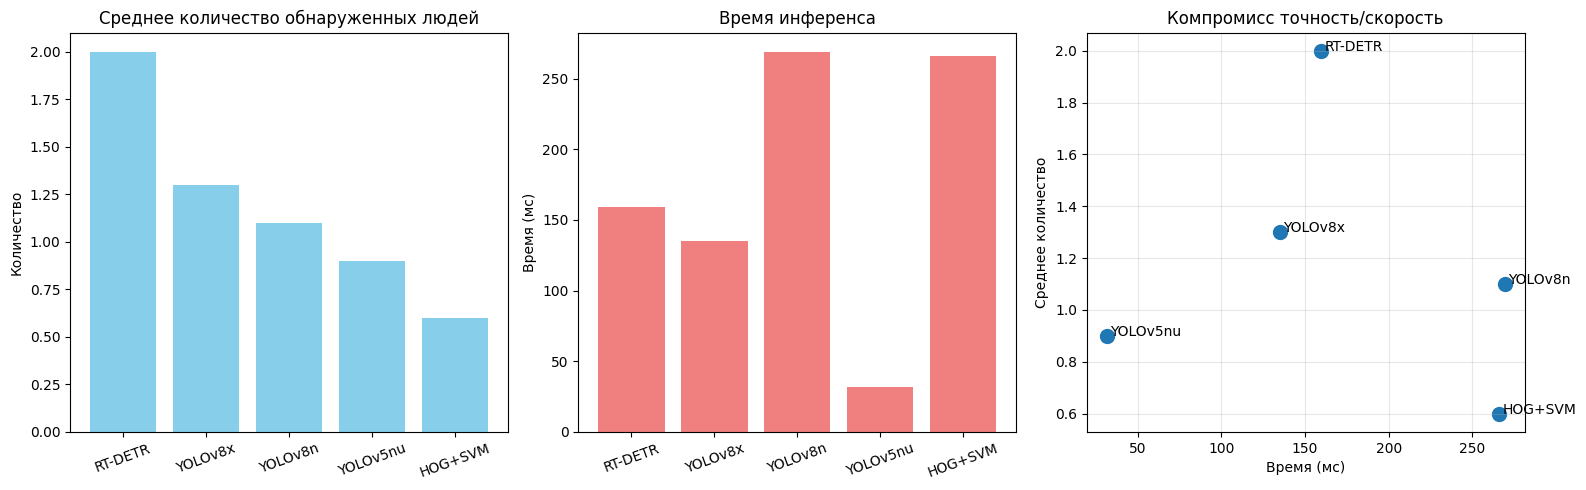


✅ Графики сохранены в /kaggle/working/results/comparison_plots.png


In [8]:
# ==============================================================================
# ЯЧЕЙКА 8: Построение графиков сравнения
# ==============================================================================

# Создание таблицы
df_data = []
for name, s in stats.items():
    df_data.append({
        "Model": name,
        "Mean Count": round(s["mean_count"], 1),
        "Max Count": s["max_count"],
        "Time (ms)": round(s["mean_time_ms"], 1),
        "Size (MB)": model_sizes.get(name, 0)
    })

df = pd.DataFrame(df_data).sort_values("Mean Count", ascending=False)

print("\n📋 ТАБЛИЦА СРАВНЕНИЯ:")
print(df.to_string(index=False))

# Графики
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Среднее количество людей
axes[0].bar(df["Model"], df["Mean Count"], color='skyblue')
axes[0].set_title("Среднее количество обнаруженных людей", fontsize=12)
axes[0].set_ylabel("Количество", fontsize=10)
axes[0].tick_params(axis='x', rotation=20)

# 2. Время инференса
axes[1].bar(df["Model"], df["Time (ms)"], color='lightcoral')
axes[1].set_title("Время инференса", fontsize=12)
axes[1].set_ylabel("Время (мс)", fontsize=10)
axes[1].tick_params(axis='x', rotation=20)

# 3. Компромисс точность/скорость
axes[2].scatter(df["Time (ms)"], df["Mean Count"], s=100)
for i, row in df.iterrows():
    axes[2].annotate(row["Model"], (row["Time (ms)"] + 2, row["Mean Count"]))
axes[2].set_xlabel("Время (мс)", fontsize=10)
axes[2].set_ylabel("Среднее количество", fontsize=10)
axes[2].set_title("Компромисс точность/скорость", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results/comparison_plots.png', dpi=150)
plt.show()

print("\n✅ Графики сохранены в /kaggle/working/results/comparison_plots.png")

In [9]:
# ==============================================================================
# ЯЧЕЙКА 9: Сохранение результатов в JSON
# ==============================================================================

report = {
    "project": {
        "name": "Crowd Counting Comparison",
        "variant": 15,
        "task": "Подсчёт людей в толпе",
        "num_images": len(img_list),
        "device": str(device)
    },
    "models": {
        name: {
            "mean_count": s["mean_count"],
            "min_count": s["min_count"],
            "max_count": s["max_count"],
            "std_count": s["std_count"],
            "mean_time_ms": s["mean_time_ms"],
            "std_time_ms": s["std_time_ms"],
            "size_mb": model_sizes.get(name, 0)
        }
        for name, s in stats.items()
    },
    "summary": {
        "best_accuracy": df.iloc[0]["Model"],
        "fastest": df.loc[df["Time (ms)"].idxmin()]["Model"],
        "best_balance": df.loc[(df["Mean Count"] / df["Time (ms)"]).idxmax()]["Model"]
    }
}

with open('/kaggle/working/results/report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("\n✅ Отчёт сохранён в /kaggle/working/results/report.json")

# Вывод рекомендаций
print("\n" + "="*60)
print("РЕКОМЕНДАЦИИ ПО ВЫБОРУ МОДЕЛИ")
print("="*60)

best_acc = df.iloc[0]
fastest = df.loc[df["Time (ms)"].idxmin()]
best_balance = df.loc[(df["Mean Count"] / df["Time (ms)"]).idxmax()]

print(f"\n🥇 Лучшая точность: {best_acc['Model']} ({best_acc['Mean Count']:.1f} чел.)")
print(f"⚡ Самая быстрая: {fastest['Model']} ({fastest['Time (ms)']:.1f} мс)")
print(f"🏆 Лучший баланс: {best_balance['Model']}")

print("\n💡 Рекомендации:")
print(f"   - Для систем реального времени → {fastest['Model']}")
print(f"   - Для максимальной точности → {best_acc['Model']}")
print(f"   - Для баланса точности/скорости → {best_balance['Model']}")


✅ Отчёт сохранён в /kaggle/working/results/report.json

РЕКОМЕНДАЦИИ ПО ВЫБОРУ МОДЕЛИ

🥇 Лучшая точность: RT-DETR (2.0 чел.)
⚡ Самая быстрая: YOLOv5nu (31.6 мс)
🏆 Лучший баланс: YOLOv5nu

💡 Рекомендации:
   - Для систем реального времени → YOLOv5nu
   - Для максимальной точности → RT-DETR
   - Для баланса точности/скорости → YOLOv5nu


In [10]:
# ==============================================================================
# ЯЧЕЙКА 10: Создание Gradio демо-интерфейса
# ==============================================================================

def process_image(img):
    """Обработка изображения всеми моделями"""
    if img is None:
        return None, "Ошибка: изображение не загружено"
    
    # Конвертация
    if len(img.shape) == 3 and img.shape[2] == 3:
        if img.dtype == np.uint8:
            img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        else:
            img_bgr = (img * 255).astype(np.uint8)
            img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_RGB2BGR)
    else:
        img_bgr = img
    
    # Подсчёт
    results = {}
    times = {}
    
    models = {
        "YOLOv8n": count_yolov8n,
        "YOLOv8n (conf=0.1)": count_yolov8n_low,
        "YOLOv8x": count_yolov8x,
        "YOLOv5nu": count_yolov5nu,
        "RT-DETR": count_rtdetr,
        "HOG+SVM": count_hog
    }
    
    for name, func in models.items():
        start = time.time()
        results[name] = func(img_bgr)
        times[name] = (time.time() - start) * 1000
    
    # Визуализация
    vis_img, count = visualize_detections(img_bgr, yolo, "YOLOv8n")
    
    # Вывод
    output = "📊 РЕЗУЛЬТАТЫ ПОДСЧЁТА:\n" + "="*36 + "\n"
    output += f"{'Модель':16} | {'Кол-во':>6} | {'Время (мс)':>10}\n"
    output += "-"*38 + "\n"
    
    for name in models:
        output += f"{name:16} | {results[name]:6d} | {times[name]:10.1f}\n"
    
    best = max(results, key=results.get)
    output += "\n" + "="*36 + "\n"
    output += f"🏆 Лучшая: {best} ({results[best]} чел.)"
    
    # Сохраняем результат
    cv2.imwrite('/kaggle/working/results/latest_result.jpg', vis_img)
    
    return vis_img, output

# Создание демо
if len(img_list) > 0:
    examples = [[img_list[0]]]
else:
    examples = None

demo = gr.Interface(
    fn=process_image,
    inputs=gr.Image(type="numpy", label="📤 Загрузите изображение с людьми"),
    outputs=[
        gr.Image(label="🔍 Детекция людей (YOLOv8)"),
        gr.Textbox(label="📊 Результаты подсчёта", lines=14)
    ],
    title="👥 Подсчёт людей в толпе (Crowd Counting)",
    description="Сравнение 6 архитектур: YOLOv8n, YOLOv8n (conf=0.1), YOLOv8x, YOLOv5nu, RT-DETR, HOG+SVM",
    examples=examples
)

print("\n🚀 Запуск Gradio демо...")
demo.launch(share=True, debug=False)


🚀 Запуск Gradio демо...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9a8cf6e2019ee12dba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [11]:
# ==============================================================================
# ЯЧЕЙКА 11: Генерация таблицы для отчёта
# ==============================================================================

print("\n" + "="*60)
print("ТАБЛИЦА ДЛЯ ОТЧЁТА (ГОСТ)")
print("="*60)

# Создаём таблицу в формате для копирования
table_data = []
for name, s in stats.items():
    table_data.append({
        "Модель": name,
        "Архитектура": {
            "YOLOv8n": "Anchor-free CNN",
            "YOLOv8x": "Anchor-free CNN (Large)",
            "YOLOv5nu": "Anchor-based CNN",
            "RT-DETR": "Vision Transformer",
            "HOG+SVM": "Classical ML"
        }.get(name, "-"),
        "Среднее кол-во": f"{s['mean_count']:.1f}",
        "Макс. кол-во": s["max_count"],
        "Время (мс)": f"{s['mean_time_ms']:.1f}",
        "Размер (Мб)": model_sizes.get(name, 0)
    })

df_report = pd.DataFrame(table_data)
print(df_report.to_string(index=False))

# Сохраняем в CSV для Excel
df_report.to_csv('/kaggle/working/results/report_table.csv', index=False)
print("\n✅ Таблица сохранена в /kaggle/working/results/report_table.csv")


ТАБЛИЦА ДЛЯ ОТЧЁТА (ГОСТ)
  Модель             Архитектура Среднее кол-во  Макс. кол-во Время (мс)  Размер (Мб)
 YOLOv8n         Anchor-free CNN            1.1             4      269.2          6.2
 YOLOv8x Anchor-free CNN (Large)            1.3             4      135.0        130.0
YOLOv5nu        Anchor-based CNN            0.9             3       31.6          5.3
 RT-DETR      Vision Transformer            2.0             9      159.5         66.2
 HOG+SVM            Classical ML            0.6             3      265.9          1.1

✅ Таблица сохранена в /kaggle/working/results/report_table.csv
